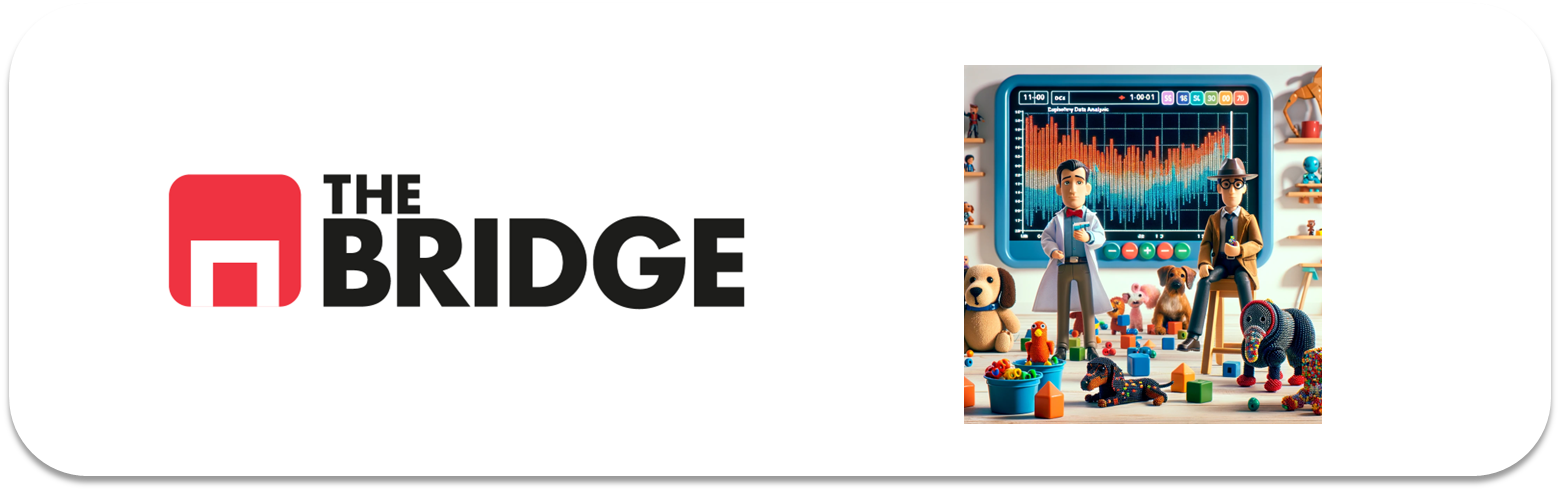

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import sys
sys.path.append(".")
import bootcampviztools as bvt


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [4]:
df = pd.read_csv("./data/titanic.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [5]:
df.drop(columns=["deck", "survived", "pclass", "embarked"], inplace=True)
df.head()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [6]:
df["family_members"] = df["parch"] + df["sibsp"]
df.drop(columns=["parch", "sibsp"], inplace=True)
df.head()

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [8]:
print(f"Nulos en embark_town: {df['embark_town'].isna().sum()}")
moda_embark = df["embark_town"].mode()[0]
df.fillna({"embark_town": moda_embark}, inplace=True)
print(f"Moda imputada: {moda_embark}")

Nulos en embark_town: 2
Moda imputada: Southampton


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [9]:
print(f"Nulos en age antes: {df['age'].isna().sum()}")

df["age"] = df.groupby("who")["age"].transform(
    lambda x: x.fillna(x.mean())
)

print(f"Nulos en age después: {df['age'].isna().sum()}")
df.groupby("who")["age"].mean()


Nulos en age antes: 177
Nulos en age después: 0


who
child     6.369518
man      33.173123
woman    32.000000
Name: age, dtype: float64

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

Absolutos:
 alive   no  yes
who            
child   34   49
man    449   88
woman   66  205

Relativos:
 alive    no   yes
who              
child  0.41  0.59
man    0.84  0.16
woman  0.24  0.76


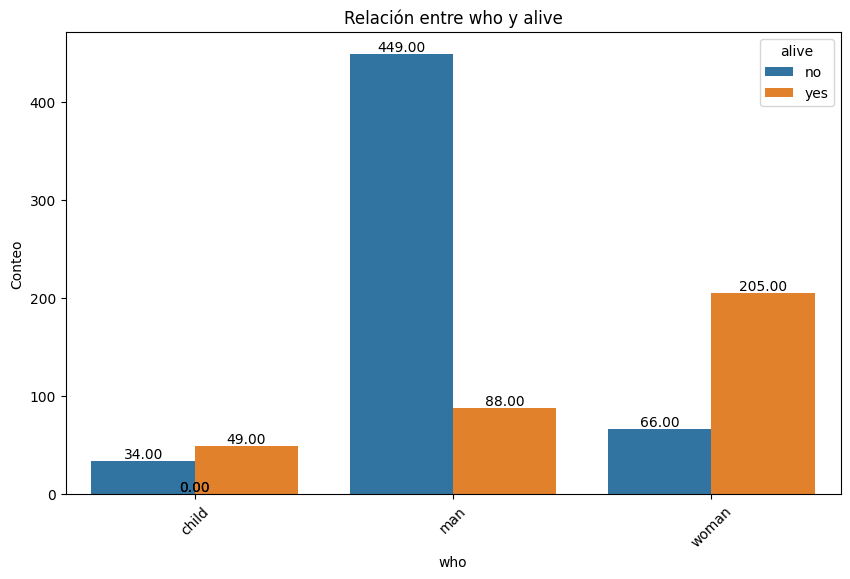

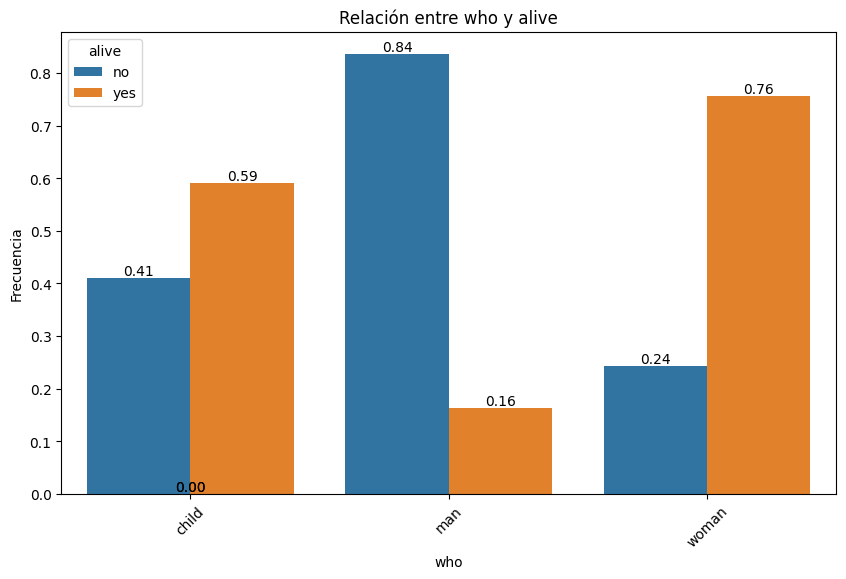


Chi2 sex vs alive: chi2=260.72, p=0.0000, dof=1
Chi2 child vs alive: chi2=15.56, p=0.0001, dof=1


In [11]:
#1.6.1
# Absolutos y relativos
abs_genero = df.groupby("who")["alive"].value_counts().unstack()
rel_genero = df.groupby("who")["alive"].value_counts(normalize=True).unstack()

print("Absolutos:\n", abs_genero)
print("\nRelativos:\n", rel_genero.round(2))

bvt.plot_categorical_relationship_fin(df, "who", "alive", relative_freq=False, show_values=True)
bvt.plot_categorical_relationship_fin(df, "who", "alive", relative_freq=True, show_values=True)

# Test Chi-cuadrado: sexo (sex) vs alive
ct_sex = pd.crosstab(df["sex"], df["alive"])
chi2, p, dof, _ = stats.chi2_contingency(ct_sex)
print(f"\nChi2 sex vs alive: chi2={chi2:.2f}, p={p:.4f}, dof={dof}")

# Test Chi-cuadrado: adulto vs niño
df["is_child"] = df["who"] == "child"
ct_child = pd.crosstab(df["is_child"], df["alive"])
chi2, p, dof, _ = stats.chi2_contingency(ct_child)
print(f"Chi2 child vs alive: chi2={chi2:.2f}, p={p:.4f}, dof={dof}")


Absolutos:
 alive         no  yes
embark_town          
Cherbourg     75   93
Queenstown    47   30
Southampton  427  219

Relativos:
 alive          no   yes
embark_town            
Cherbourg    0.45  0.55
Queenstown   0.61  0.39
Southampton  0.66  0.34


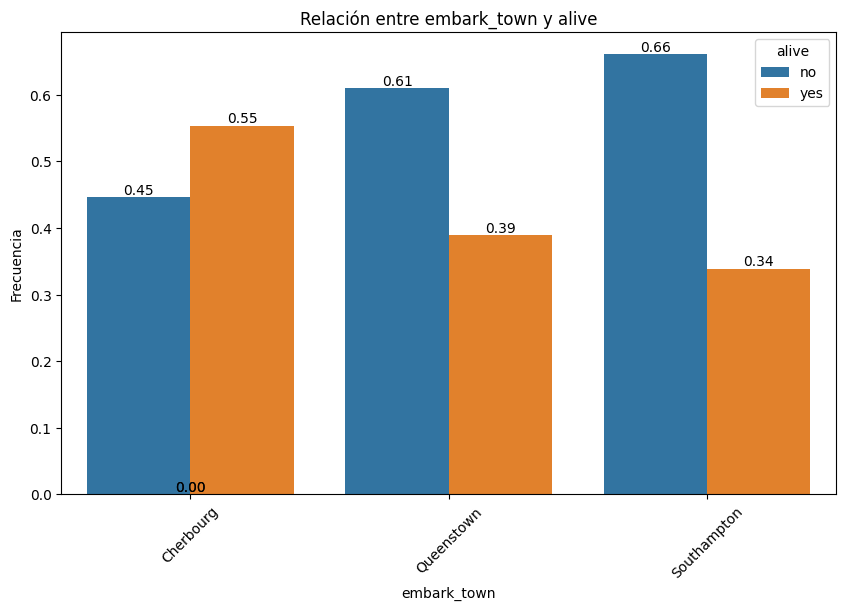


Chi2 embark_town vs alive: chi2=25.96, p=0.0000, dof=2


In [14]:
#1.6.2


abs_ciudad = df.groupby("embark_town")["alive"].value_counts().unstack()
rel_ciudad = df.groupby("embark_town")["alive"].value_counts(normalize=True).unstack()

print("Absolutos:\n", abs_ciudad)
print("\nRelativos:\n", rel_ciudad.round(2))

bvt.plot_categorical_relationship_fin(df, "embark_town", "alive", relative_freq=True, show_values=True)

ct_town = pd.crosstab(df["embark_town"], df["alive"])
chi2, p, dof, _ = stats.chi2_contingency(ct_town)
print(f"\nChi2 embark_town vs alive: chi2={chi2:.2f}, p={p:.4f}, dof={dof}")


Absolutos:
 alive         no  yes
embark_town          
Cherbourg     75   93
Queenstown    47   30
Southampton  427  219

Relativos:
 alive          no   yes
embark_town            
Cherbourg    0.45  0.55
Queenstown   0.61  0.39
Southampton  0.66  0.34


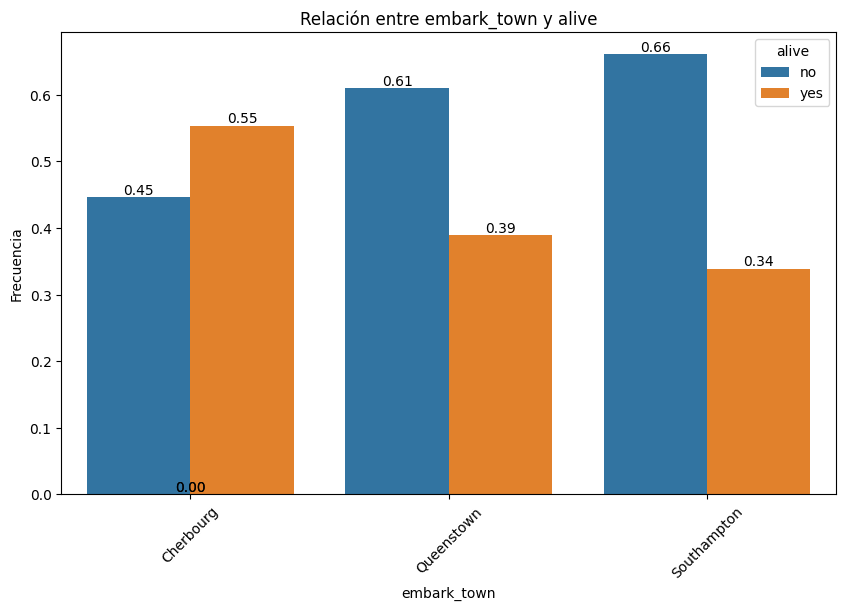


Chi2 embark_town vs alive: chi2=25.96, p=0.0000, dof=2


In [15]:
#1.6.3
abs_ciudad = df.groupby("embark_town")["alive"].value_counts().unstack()
rel_ciudad = df.groupby("embark_town")["alive"].value_counts(normalize=True).unstack()

print("Absolutos:\n", abs_ciudad)
print("\nRelativos:\n", rel_ciudad.round(2))

bvt.plot_categorical_relationship_fin(df, "embark_town", "alive", relative_freq=True, show_values=True)

ct_town = pd.crosstab(df["embark_town"], df["alive"])
chi2, p, dof, _ = stats.chi2_contingency(ct_town)
print(f"\nChi2 embark_town vs alive: chi2={chi2:.2f}, p={p:.4f}, dof={dof}")


       count   mean    std  min    25%   50%   75%     max
alive                                                     
no     549.0  22.12  31.39  0.0   7.85  10.5  26.0  263.00
yes    342.0  48.40  66.60  0.0  12.48  26.0  57.0  512.33


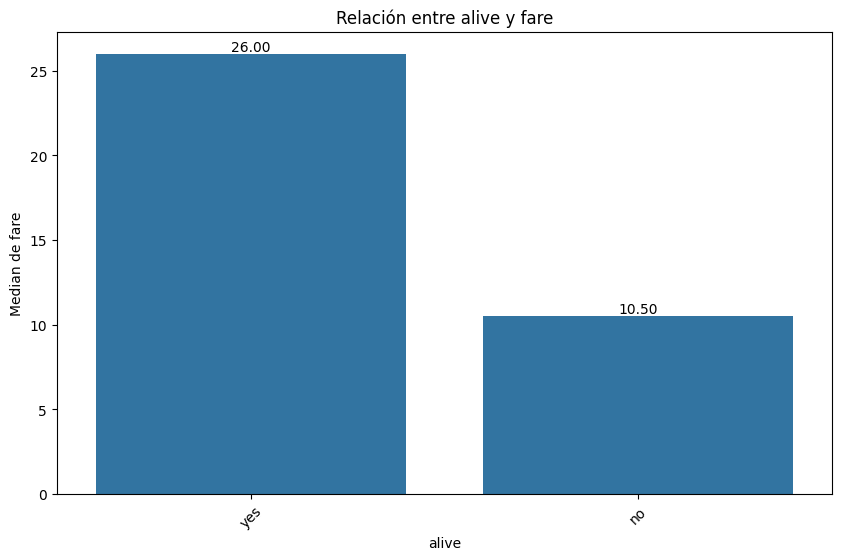

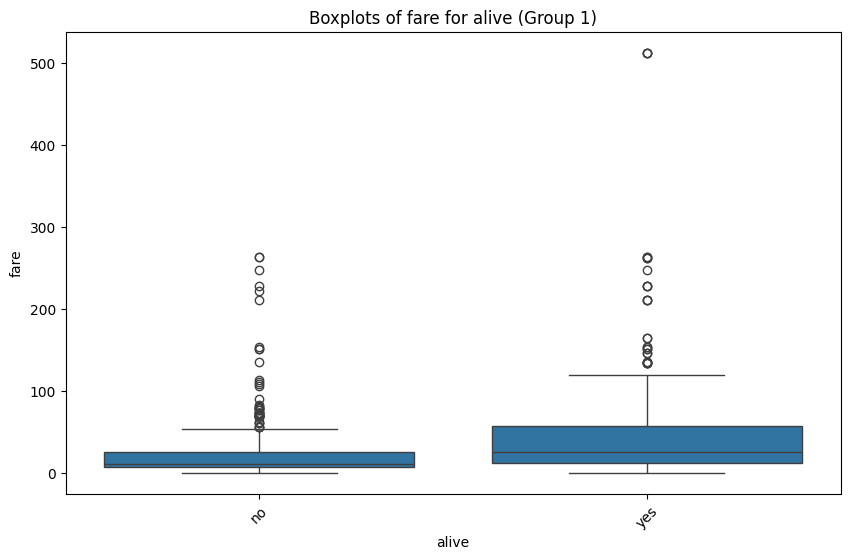


Mann-Whitney fare vs alive: U=129952, p=0.0000


In [18]:
#1.6.4
print(df.groupby("alive")["fare"].describe().round(2))

bvt.plot_categorical_numerical_relationship(df, "alive", "fare", show_values=True, measure="median")
bvt.plot_grouped_boxplots(df, "alive", "fare")

vivos = df[df["alive"] == "yes"]["fare"]
fallecidos = df[df["alive"] == "no"]["fare"]
stat, p = stats.mannwhitneyu(vivos, fallecidos, alternative="two-sided")
print(f"\nMann-Whitney fare vs alive: U={stat:.0f}, p={p:.4f}")


In [19]:
#1.6.5

sin_billete = df[df["fare"] == 0]
print(f"Pasajeros con fare=0: {len(sin_billete)}")
print(sin_billete[["sex", "who", "class", "embark_town", "alive", "family_members"]])

# El pasajero que más pagó
max_fare = df.loc[df["fare"].idxmax()]
print(f"\nPasajero con fare más alto:\n{max_fare}")


Pasajeros con fare=0: 15
      sex  who   class  embark_town alive  family_members
179  male  man   Third  Southampton    no               0
263  male  man   First  Southampton    no               0
271  male  man   Third  Southampton   yes               0
277  male  man  Second  Southampton    no               0
302  male  man   Third  Southampton    no               0
413  male  man  Second  Southampton    no               0
466  male  man  Second  Southampton    no               0
481  male  man  Second  Southampton    no               0
597  male  man   Third  Southampton    no               0
633  male  man   First  Southampton    no               0
674  male  man  Second  Southampton    no               0
732  male  man  Second  Southampton    no               0
806  male  man   First  Southampton    no               0
815  male  man   First  Southampton    no               0
822  male  man   First  Southampton    no               0

Pasajero con fare más alto:
sex               

Mediana del fare por ciudad y supervivencia:
 alive           no    yes
embark_town              
Cherbourg    14.46  56.93
Queenstown    7.75   7.81
Southampton  10.50  26.00


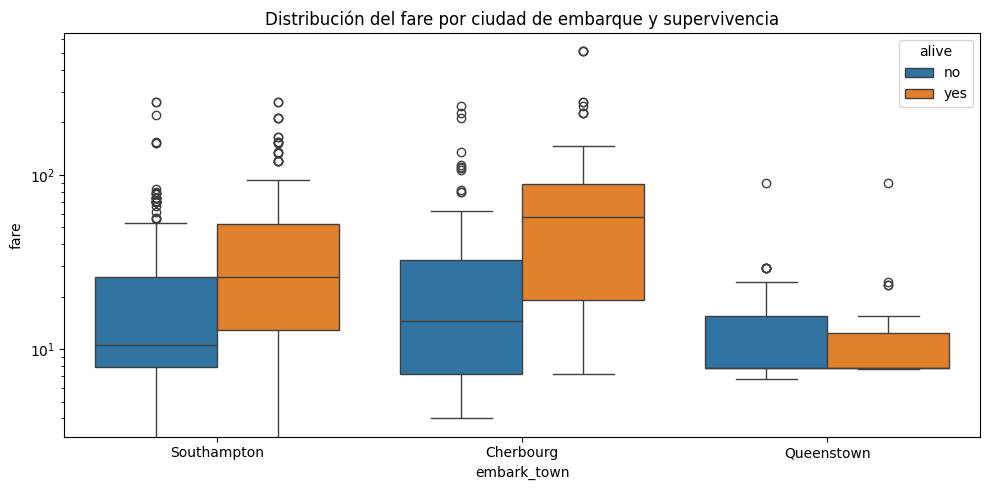

In [20]:
#1.6.6

pivot = df.pivot_table(values="fare", index="embark_town", columns="alive", aggfunc="median")
print("Mediana del fare por ciudad y supervivencia:\n", pivot.round(2))

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="embark_town", y="fare", hue="alive")
plt.title("Distribución del fare por ciudad de embarque y supervivencia")
plt.yscale("log")
plt.tight_layout()
plt.show()


Absolutos:
 alive              no  yes
class  age_group          
First  niño         1    8
       joven       33   70
       adulto      35   55
       mayor       11    3
Second niño         2   19
       joven       64   49
       adulto      29   18
       mayor        2    1
Third  niño        42   28
       joven      273   85
       adulto      53    5
       mayor        4    1

Relativos:
 alive               no   yes
class  age_group            
First  niño       0.11  0.89
       joven      0.32  0.68
       adulto     0.39  0.61
       mayor      0.79  0.21
Second niño       0.10  0.90
       joven      0.57  0.43
       adulto     0.62  0.38
       mayor      0.67  0.33
Third  niño       0.60  0.40
       joven      0.76  0.24
       adulto     0.91  0.09
       mayor      0.80  0.20


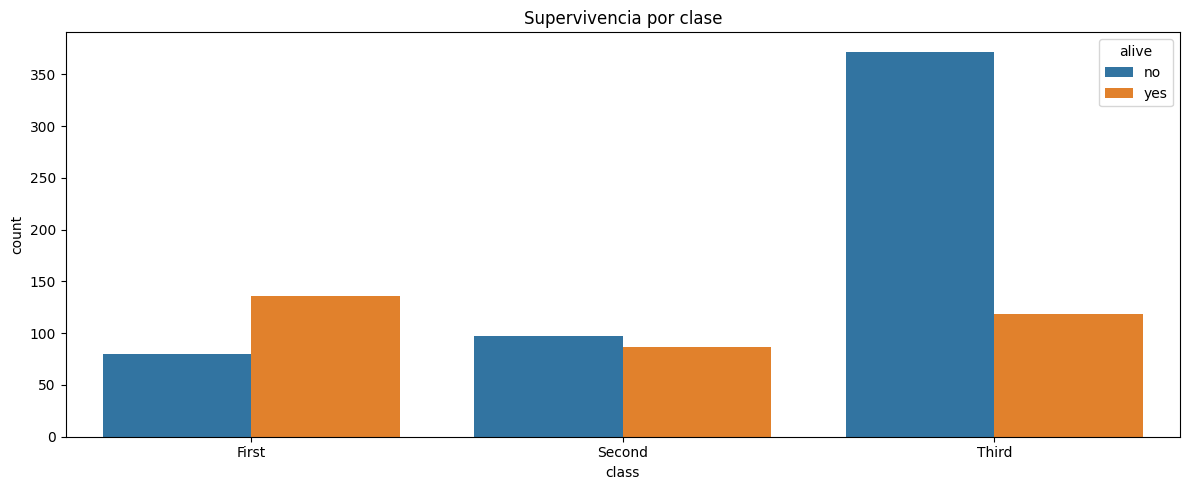

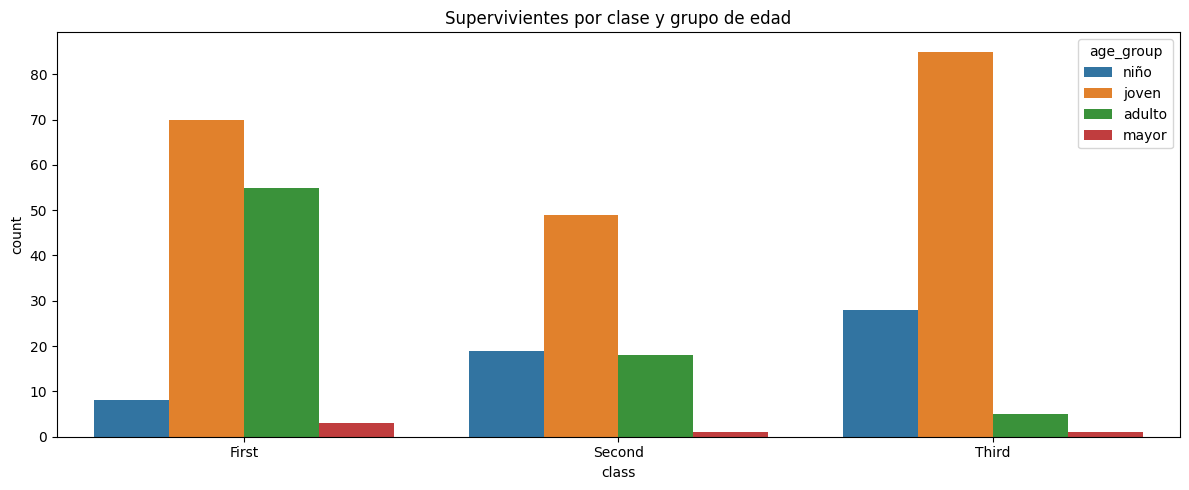

In [21]:
#1.6.7

df["age_group"] = pd.cut(df["age"], bins=[0, 16, 35, 60, 100],
                         labels=["niño", "joven", "adulto", "mayor"])

abs_grupo = df.groupby(["class", "age_group"])["alive"].value_counts().unstack().fillna(0)
rel_grupo = df.groupby(["class", "age_group"])["alive"].value_counts(normalize=True).unstack().fillna(0)

print("Absolutos:\n", abs_grupo)
print("\nRelativos:\n", rel_grupo.round(2))

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="class", hue="alive", order=["First", "Second", "Third"])
plt.title("Supervivencia por clase")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(data=df[df["alive"] == "yes"], x="class", hue="age_group",
              order=["First", "Second", "Third"])
plt.title("Supervivientes por clase y grupo de edad")
plt.tight_layout()
plt.show()


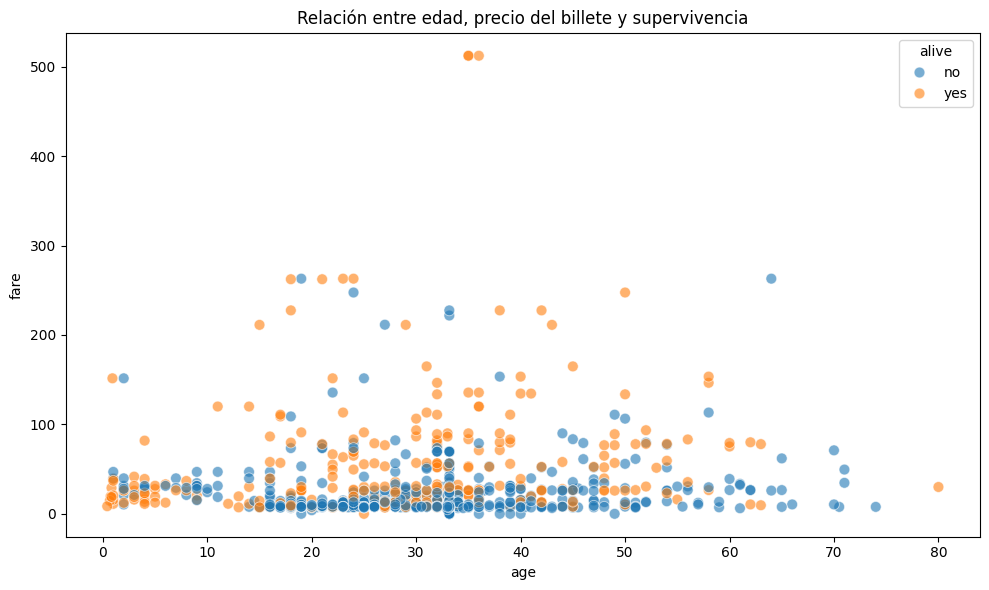

Correlación age-fare (no): 0.063
Correlación age-fare (yes): 0.144


In [22]:
#1.6.8

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="fare", hue="alive", alpha=0.6, s=60)
plt.title("Relación entre edad, precio del billete y supervivencia")
plt.tight_layout()
plt.show()

# Correlaciones por grupo
for grupo, subdf in df.groupby("alive"):
    corr = subdf[["age", "fare"]].corr().iloc[0, 1]
    print(f"Correlación age-fare ({grupo}): {corr:.3f}")


## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?